## Grace Burns
## NorthWestern University
## Jan 2026

# Phase 2 EDA — PostgreSQL Star Schema
## Group 7 | Retail Customer Behavior for Growth | Burns G.

Reproduces the three Phase 1 EDA research questions against the properly structured PostgreSQL star schema.

| Section | Question | Phase 1 finding to reproduce |
|---------|----------|-------------------------------|
| 1 | Customer spending trends | Wks 1–16 ramp-up artefact; steady-state $75K–$95K/wk; Wk 102 truncation |
| 2 | Demographic influences | classification_3 strongest (~$7K spread); classification_2 Group X +$1K premium |
| 3 | Product category growth | GROCERY 60–70%; top 5 depts = 85%+; DRUG GM #2 |
| Bonus | Campaign selection bias | 14× exposure gap bottom vs top spend quintile |

> **Why re-run in PostgreSQL?** Phase 1 EDA ran against raw CSV files in Google Drive.
> Phase 2 uses the star schema with `ext_calendar` for date anchoring — results are
> directly comparable to MongoDB and modelling notebook outputs.

In [1]:
import socket

def check_port(host, port):
    s = socket.socket()
    s.settimeout(2)
    try:
        s.connect((host, port))
        s.close()
        print(f"OPEN: {host}:{port}")
    except Exception as e:
        print(f"CLOSED: {host}:{port} -> {e}")

check_port("127.0.0.1", 5434)
check_port("127.0.0.1", 5432)

OPEN: 127.0.0.1:5434
OPEN: 127.0.0.1:5432


In [2]:
import os
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sqlalchemy import create_engine, text

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')

PG_URL = (
    f"postgresql+psycopg2://"
    f"{os.getenv('PG_USER','retail_user')}:{os.getenv('PG_PASSWORD','retail_pass')}"
    f"@{os.getenv('PG_HOST','localhost')}:{os.getenv('PG_PORT','5434')}"
    f"/{os.getenv('PG_DB','retail_analytics')}"
)

engine = create_engine(PG_URL, pool_pre_ping=True)

with engine.connect() as c:
    ver = c.execute(text('SELECT version()')).scalar().split(',')[0]
    n_txn = c.execute(text('SELECT COUNT(*) FROM fact_transactions')).scalar()
    n_hh  = c.execute(text('SELECT COUNT(*) FROM dim_households')).scalar()

print(f'PostgreSQL : {ver}')
print(f'fact_transactions : {n_txn:,} rows')
print(f'dim_households    : {n_hh:,} rows')

PostgreSQL : PostgreSQL 16.13 (Debian 16.13-1.pgdg13+1) on x86_64-pc-linux-gnu
fact_transactions : 1,427,303 rows
dim_households    : 924 rows


---
## Section 1 — Customer Spending Trends

Phase 1 finding: Weeks 1–16 are a ramp-up artefact (panel recruitment); steady state is $75K–$95K/wk;
Week 102 is a hard truncation. Now reproduced using `ext_calendar` for proper week mapping.

In [3]:
SQL_WEEKLY = '''
SELECT
    ec.week_num,
    MIN(ec.calendar_date)                        AS week_start_date,
    COUNT(DISTINCT ft.basket_id)                 AS baskets,
    COUNT(DISTINCT ft.household_key)             AS active_households,
    ROUND(SUM(ft.sales_value)::numeric, 2)       AS total_spend,
    ROUND(SUM(ft.sales_value) /
          NULLIF(COUNT(DISTINCT ft.household_key),0), 2) AS spend_per_hh,
    CASE
        WHEN ec.is_rampup     THEN 'Ramp-up (Wks 1-16)'
        WHEN ec.is_truncation THEN 'Truncation (Wk 102)'
        ELSE 'Steady state'
    END AS window_flag
FROM fact_transactions ft
JOIN ext_calendar ec ON ec.day_int = ft.day
GROUP BY ec.week_num, ec.is_rampup, ec.is_truncation
ORDER BY ec.week_num
'''

with engine.connect() as c:
    df_weekly = pd.read_sql(text(SQL_WEEKLY), c)

df_weekly['week_start_date'] = pd.to_datetime(df_weekly['week_start_date'])
print(f'Weeks observed : {len(df_weekly)}')
print(f'  Ramp-up      : {(df_weekly.window_flag=="Ramp-up (Wks 1-16)").sum()}')
print(f'  Steady state : {(df_weekly.window_flag=="Steady state").sum()}')
print(f'  Truncation   : {(df_weekly.window_flag=="Truncation (Wk 102)").sum()}')
display(df_weekly.head(5))

Weeks observed : 102
  Ramp-up      : 16
  Steady state : 85
  Truncation   : 1


,week_num,week_start_date,baskets,active_households,total_spend,spend_per_hh,window_flag
0,1,2023-01-01,64,42,2743.94,65.33,Ramp-up (Wks 1-16)
1,2,2023-01-08,143,68,4430.97,65.16,Ramp-up (Wks 1-16)
2,3,2023-01-15,192,99,6453.21,65.18,Ramp-up (Wks 1-16)
3,4,2023-01-22,226,109,7783.67,71.41,Ramp-up (Wks 1-16)
4,5,2023-01-29,330,159,10826.39,68.09,Ramp-up (Wks 1-16)


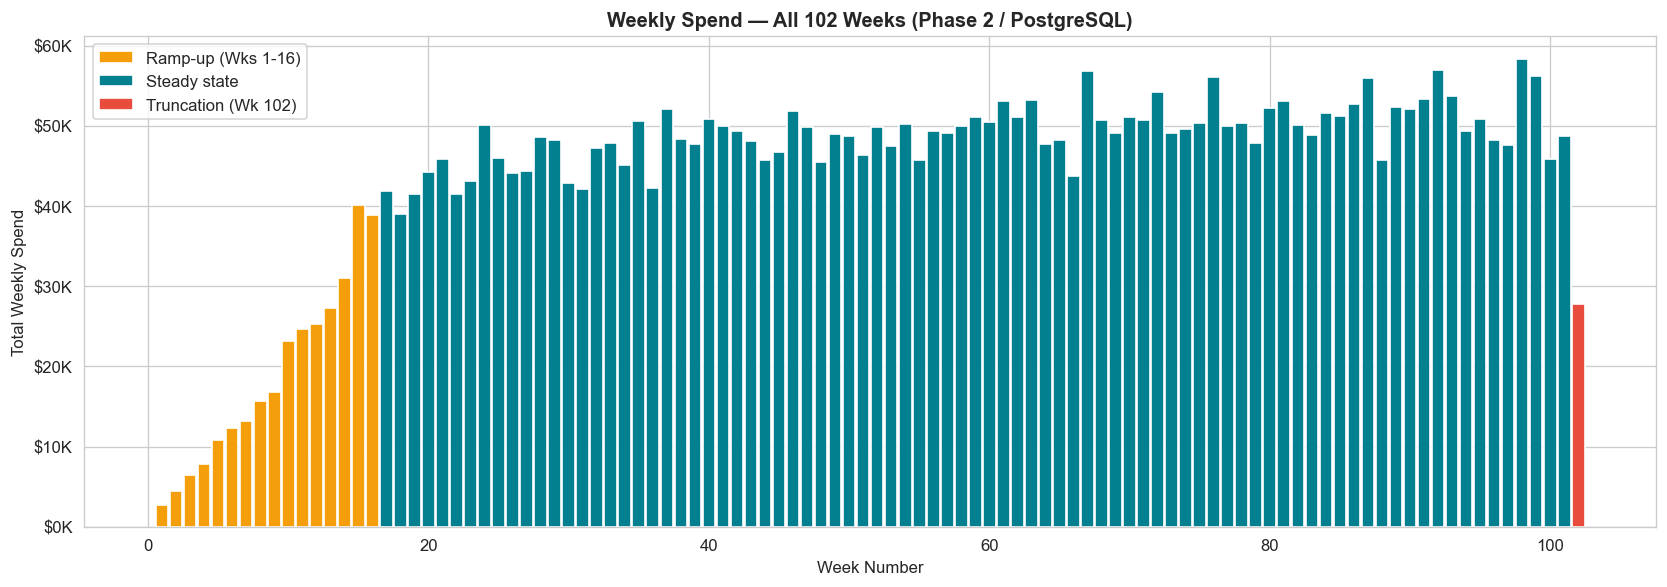


Steady-state summary ($):
  Min weekly spend : $38,996
  Max weekly spend : $58,304
  Avg weekly spend : $49,050
  Median           : $49,329


In [4]:
# Chart: Weekly spend with artefact windows highlighted
fig, ax = plt.subplots(figsize=(14, 5))

colors = {'Ramp-up (Wks 1-16)':'#F59E0B', 'Steady state':'#028090', 'Truncation (Wk 102)':'#E74C3C'}

for flag, grp in df_weekly.groupby('window_flag'):
    ax.bar(grp['week_num'], grp['total_spend'], color=colors[flag], label=flag, width=0.9)

ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
ax.set_xlabel('Week Number')
ax.set_ylabel('Total Weekly Spend')
ax.set_title('Weekly Spend — All 102 Weeks (Phase 2 / PostgreSQL)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Steady-state statistics
ss = df_weekly[df_weekly.window_flag == 'Steady state']
print('\nSteady-state summary ($):')
print(f'  Min weekly spend : ${ss.total_spend.min():,.0f}')
print(f'  Max weekly spend : ${ss.total_spend.max():,.0f}')
print(f'  Avg weekly spend : ${ss.total_spend.mean():,.0f}')
print(f'  Median           : ${ss.total_spend.median():,.0f}')

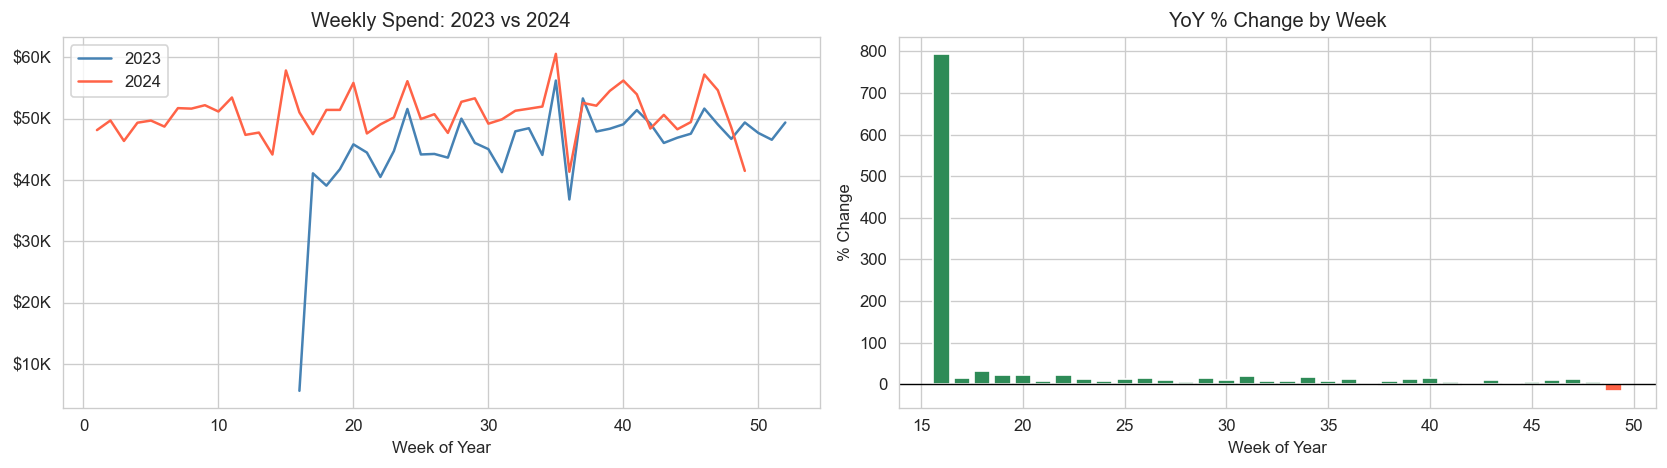


Avg YoY change:  33.52 %


In [5]:
# YoY comparison (2023 vs 2024)
SQL_YOY = '''
SELECT
    ec.week_of_year,
    ROUND(SUM(ft.sales_value) FILTER (WHERE ec.year = 2023)::numeric, 2) AS spend_2023,
    ROUND(SUM(ft.sales_value) FILTER (WHERE ec.year = 2024)::numeric, 2) AS spend_2024
FROM fact_transactions ft
JOIN ext_calendar ec ON ec.day_int = ft.day
WHERE ec.is_rampup = FALSE AND ec.is_truncation = FALSE
GROUP BY ec.week_of_year
ORDER BY ec.week_of_year
'''
with engine.connect() as c:
    df_yoy = pd.read_sql(text(SQL_YOY), c)

df_yoy['yoy_change_pct'] = (
    (df_yoy.spend_2024 - df_yoy.spend_2023) /
    df_yoy.spend_2023.replace(0, float('nan')) * 100
).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(df_yoy.week_of_year, df_yoy.spend_2023, label='2023', color='steelblue')
axes[0].plot(df_yoy.week_of_year, df_yoy.spend_2024, label='2024', color='tomato')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1000:.0f}K'))
axes[0].set_title('Weekly Spend: 2023 vs 2024')
axes[0].set_xlabel('Week of Year')
axes[0].legend()

axes[1].bar(df_yoy.week_of_year, df_yoy.yoy_change_pct,
            color=['tomato' if v < 0 else 'seagreen' for v in df_yoy.yoy_change_pct])
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('YoY % Change by Week')
axes[1].set_xlabel('Week of Year')
axes[1].set_ylabel('% Change')

plt.tight_layout()
plt.show()
print('\nAvg YoY change: ', df_yoy.yoy_change_pct.mean().round(2), '%')

---
## Section 2 — Demographic Influences on Spend

Phase 1 finding: `classification_3` has the strongest spend predictive signal (~$7K spread across 12 levels).
`classification_2` Group X spends ~$1K more than Y/Z.

**Important:** Classification columns are in `dim_demographics`, NOT `dim_households`.
Join path: `fact_transactions` → `dim_demographics` (via `household_key`).

,classification,n_levels,min_group_avg,max_group_avg,spend_spread,signal_rank
0,classification_3,12,646.0,27860.0,6693.0,1
1,classification_1,6,646.0,27860.0,2162.0,2
2,classification_4,5,646.0,27860.0,1717.0,3
3,classification_5,5,646.0,27860.0,1666.0,4
4,classification_6,6,646.0,27860.0,1642.0,5
5,classification_7,4,646.0,27860.0,1465.0,6
6,classification_2,3,646.0,27860.0,1018.0,7


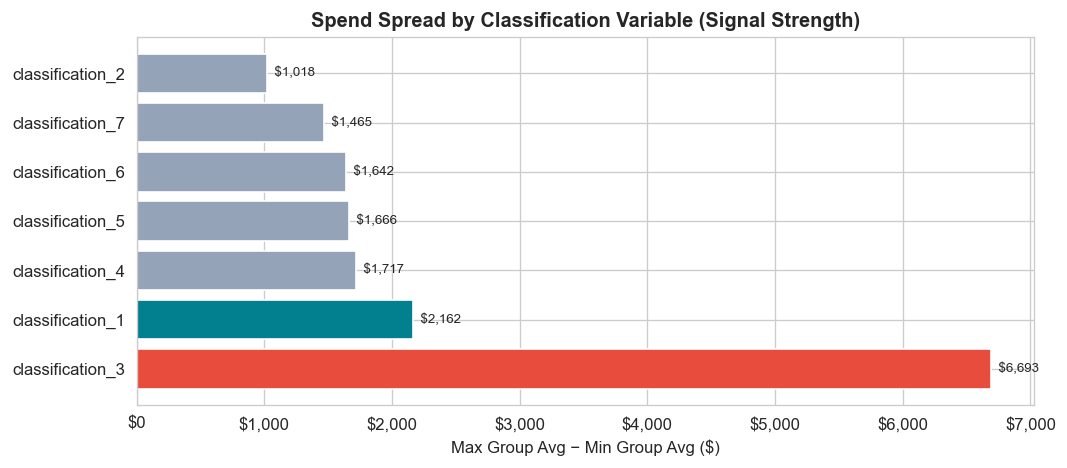

In [6]:
# Signal strength: all 7 classifications ranked by spend spread
SQL_SIGNAL = '''
WITH hh_spend AS (
    SELECT household_key, SUM(sales_value) AS lifetime_spend
    FROM fact_transactions GROUP BY household_key
),
c1 AS (SELECT 'classification_1' AS cls, dd.classification_1::text AS lvl,
        AVG(hs.lifetime_spend) AS avg_s, MAX(hs.lifetime_spend) AS max_s, MIN(hs.lifetime_spend) AS min_s
        FROM hh_spend hs JOIN dim_demographics dd ON dd.household_key = hs.household_key
        GROUP BY dd.classification_1),
c2 AS (SELECT 'classification_2', dd.classification_2::text,
        AVG(hs.lifetime_spend), MAX(hs.lifetime_spend), MIN(hs.lifetime_spend)
        FROM hh_spend hs JOIN dim_demographics dd ON dd.household_key = hs.household_key
        GROUP BY dd.classification_2),
c3 AS (SELECT 'classification_3', dd.classification_3::text,
        AVG(hs.lifetime_spend), MAX(hs.lifetime_spend), MIN(hs.lifetime_spend)
        FROM hh_spend hs JOIN dim_demographics dd ON dd.household_key = hs.household_key
        GROUP BY dd.classification_3),
c4 AS (SELECT 'classification_4', dd.classification_4::text,
        AVG(hs.lifetime_spend), MAX(hs.lifetime_spend), MIN(hs.lifetime_spend)
        FROM hh_spend hs JOIN dim_demographics dd ON dd.household_key = hs.household_key
        GROUP BY dd.classification_4),
c5 AS (SELECT 'classification_5', dd.classification_5::text,
        AVG(hs.lifetime_spend), MAX(hs.lifetime_spend), MIN(hs.lifetime_spend)
        FROM hh_spend hs JOIN dim_demographics dd ON dd.household_key = hs.household_key
        GROUP BY dd.classification_5),
c6 AS (SELECT 'classification_6', dd.classification_6::text,
        AVG(hs.lifetime_spend), MAX(hs.lifetime_spend), MIN(hs.lifetime_spend)
        FROM hh_spend hs JOIN dim_demographics dd ON dd.household_key = hs.household_key
        GROUP BY dd.classification_6),
c7 AS (SELECT 'classification_7', dd.classification_7::text,
        AVG(hs.lifetime_spend), MAX(hs.lifetime_spend), MIN(hs.lifetime_spend)
        FROM hh_spend hs JOIN dim_demographics dd ON dd.household_key = hs.household_key
        GROUP BY dd.classification_7),
all_cls AS (
    SELECT * FROM c1 UNION ALL SELECT * FROM c2 UNION ALL SELECT * FROM c3
    UNION ALL SELECT * FROM c4 UNION ALL SELECT * FROM c5
    UNION ALL SELECT * FROM c6 UNION ALL SELECT * FROM c7
)
SELECT cls AS classification,
       COUNT(DISTINCT lvl) AS n_levels,
       ROUND(MIN(min_s)::numeric,0) AS min_group_avg,
       ROUND(MAX(max_s)::numeric,0) AS max_group_avg,
       ROUND((MAX(avg_s) - MIN(avg_s))::numeric,0) AS spend_spread,
       RANK() OVER (ORDER BY (MAX(avg_s) - MIN(avg_s)) DESC) AS signal_rank
FROM all_cls
GROUP BY cls
ORDER BY spend_spread DESC
'''
with engine.connect() as c:
    df_signal = pd.read_sql(text(SQL_SIGNAL), c)

display(df_signal)

fig, ax = plt.subplots(figsize=(9, 4))
clrs = ['#E74C3C' if r == 1 else '#028090' if r == 2 else '#94A3B8'
        for r in df_signal.signal_rank]
ax.barh(df_signal.classification, df_signal.spend_spread, color=clrs)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_title('Spend Spread by Classification Variable (Signal Strength)', fontweight='bold')
ax.set_xlabel('Max Group Avg − Min Group Avg ($)')
for i, v in enumerate(df_signal.spend_spread):
    ax.text(v, i, f'  ${v:,.0f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

,classification_3,n_households,avg_lifetime_spend,median_spend,min_spend,max_spend
0,Level12,11,10789.90,11938.20,1523.80,17152.63
1,Level10,11,8548.46,6644.85,1103.88,23646.92
2,Level9,30,8394.84,8437.10,1132.40,18494.14
3,Level8,38,7912.06,6004.79,1095.10,27859.68
4,Level7,34,5927.74,5949.72,1510.63,19194.42
5,Level6,96,5822.53,4881.04,1290.68,17548.27
6,Level11,5,5726.49,5399.64,2206.06,10435.96
7,Level5,192,5702.35,4980.15,748.88,17295.18
8,Level1,61,5559.61,4827.80,1602.00,19153.75
9,Level3,77,4938.07,4405.47,760.45,19299.86



Spend spread: $6,693


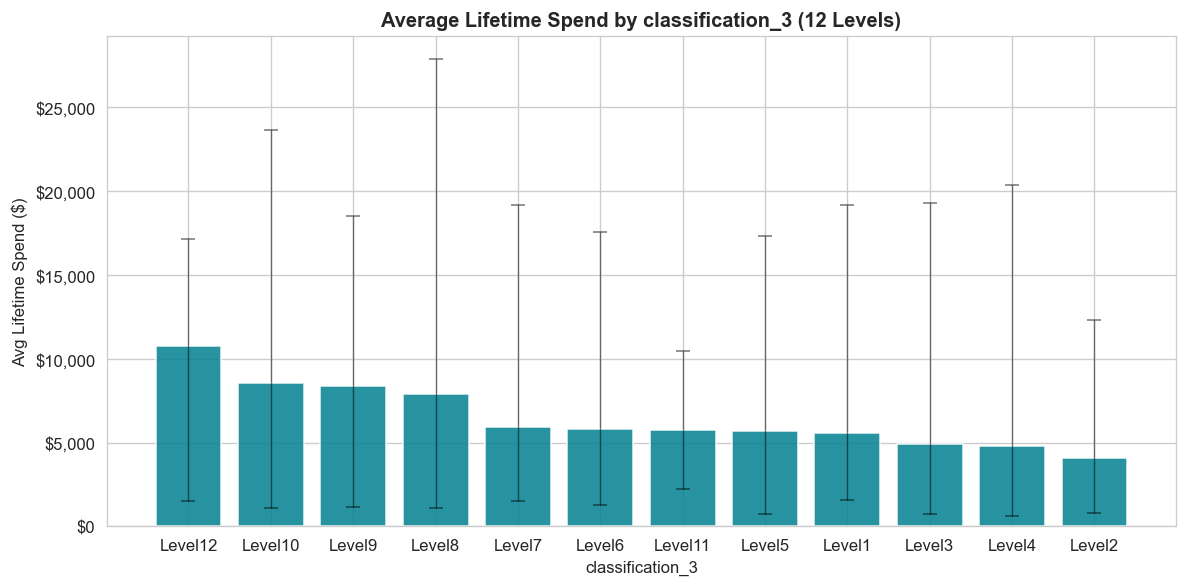

In [7]:
# classification_3: full breakdown (12 levels)
SQL_C3 = '''
WITH hh_spend AS (
    SELECT household_key, SUM(sales_value) AS lifetime_spend
    FROM fact_transactions GROUP BY household_key
)
SELECT
    dd.classification_3,
    COUNT(DISTINCT hs.household_key)             AS n_households,
    ROUND(AVG(hs.lifetime_spend)::numeric, 2)    AS avg_lifetime_spend,
    ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP
          (ORDER BY hs.lifetime_spend)::numeric, 2) AS median_spend,
    ROUND(MIN(hs.lifetime_spend)::numeric, 2)    AS min_spend,
    ROUND(MAX(hs.lifetime_spend)::numeric, 2)    AS max_spend
FROM hh_spend hs
JOIN dim_demographics dd ON dd.household_key = hs.household_key
GROUP BY dd.classification_3
ORDER BY avg_lifetime_spend DESC
'''
with engine.connect() as c:
    df_c3 = pd.read_sql(text(SQL_C3), c)

display(df_c3)
print(f'\nSpend spread: ${df_c3.avg_lifetime_spend.max() - df_c3.avg_lifetime_spend.min():,.0f}')

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(df_c3.classification_3.astype(str), df_c3.avg_lifetime_spend, color='#028090', alpha=0.85)
ax.errorbar(range(len(df_c3)),
            df_c3.avg_lifetime_spend,
            yerr=[df_c3.avg_lifetime_spend - df_c3.min_spend,
                  df_c3.max_spend - df_c3.avg_lifetime_spend],
            fmt='none', color='black', capsize=4, linewidth=0.8, alpha=0.5)
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_title('Average Lifetime Spend by classification_3 (12 Levels)', fontweight='bold')
ax.set_xlabel('classification_3')
ax.set_ylabel('Avg Lifetime Spend ($)')
plt.tight_layout()
plt.show()

,classification_2,n_households,avg_lifetime_spend,median_spend,pct_of_total_spend
0,X,340,6136.65,5055.86,46.4
1,Y,344,5268.64,4450.50,40.3
2,Z,117,5118.33,4526.21,13.3



Top group (X) premium over #2: $868


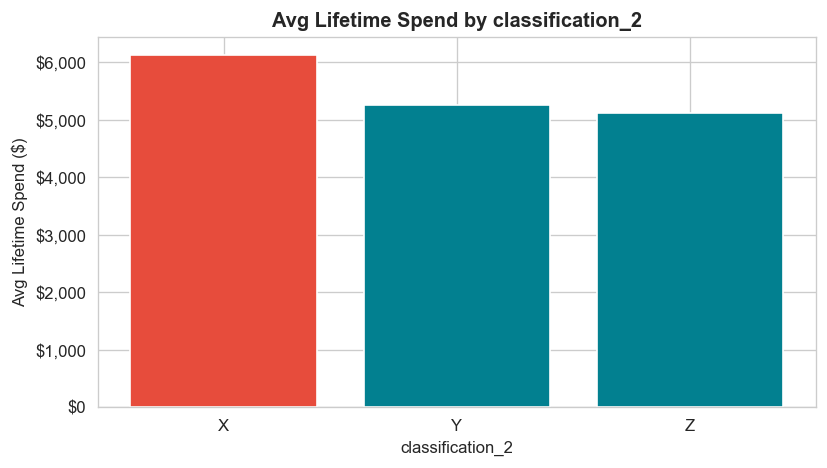

In [8]:
# classification_2: Group X premium
SQL_C2 = '''
WITH hh_spend AS (
    SELECT household_key, SUM(sales_value) AS lifetime_spend
    FROM fact_transactions GROUP BY household_key
)
SELECT
    dd.classification_2,
    COUNT(DISTINCT hs.household_key)             AS n_households,
    ROUND(AVG(hs.lifetime_spend)::numeric, 2)    AS avg_lifetime_spend,
    ROUND(PERCENTILE_CONT(0.50) WITHIN GROUP
          (ORDER BY hs.lifetime_spend)::numeric, 2) AS median_spend,
    ROUND(SUM(hs.lifetime_spend)::numeric / SUM(SUM(hs.lifetime_spend)) OVER () * 100, 1)
                                                 AS pct_of_total_spend
FROM hh_spend hs
JOIN dim_demographics dd ON dd.household_key = hs.household_key
GROUP BY dd.classification_2
ORDER BY avg_lifetime_spend DESC
'''
with engine.connect() as c:
    df_c2 = pd.read_sql(text(SQL_C2), c)

display(df_c2)

# Show the premium of the top group over others
top_avg = df_c2.avg_lifetime_spend.iloc[0]
second_avg = df_c2.avg_lifetime_spend.iloc[1]
print(f'\nTop group ({df_c2.classification_2.iloc[0]}) premium over #{2}: '
      f'${top_avg - second_avg:,.0f}')

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(df_c2.classification_2.astype(str), df_c2.avg_lifetime_spend,
       color=['#E74C3C' if i==0 else '#028090' for i in range(len(df_c2))])
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x:,.0f}'))
ax.set_title('Avg Lifetime Spend by classification_2', fontweight='bold')
ax.set_xlabel('classification_2')
ax.set_ylabel('Avg Lifetime Spend ($)')
plt.tight_layout()
plt.show()

---
## Section 3 — Product Category Growth

Phase 1 finding: GROCERY = 60–70% of revenue; top 5 departments = 85%+; DRUG GM = #2 by revenue.
Produce and Deli show highest week-on-week growth rates in steady state.

,department,total_revenue,revenue_share_pct,cumulative_share_pct,n_households,revenue_rank
0,GROCERY,2091516.35,50.17,50.2,801,1
1,DRUG GM,541608.95,12.99,63.2,801,2
2,KIOSK-GAS,327128.91,7.85,71.0,550,3
3,PRODUCE,302350.73,7.25,78.3,801,4
4,MEAT,270050.87,6.48,84.7,789,5
5,MEAT-PCKGD,192302.12,4.61,89.3,792,6
6,DELI,136417.71,3.27,92.6,776,7
7,MISC SALES TRAN,67243.50,1.61,94.2,602,8
8,PASTRY,60646.59,1.45,95.7,788,9
9,NUTRITION,56607.38,1.36,97.0,665,10



Top 5 department cumulative share: 84.7%
GROCERY share: 50.2%


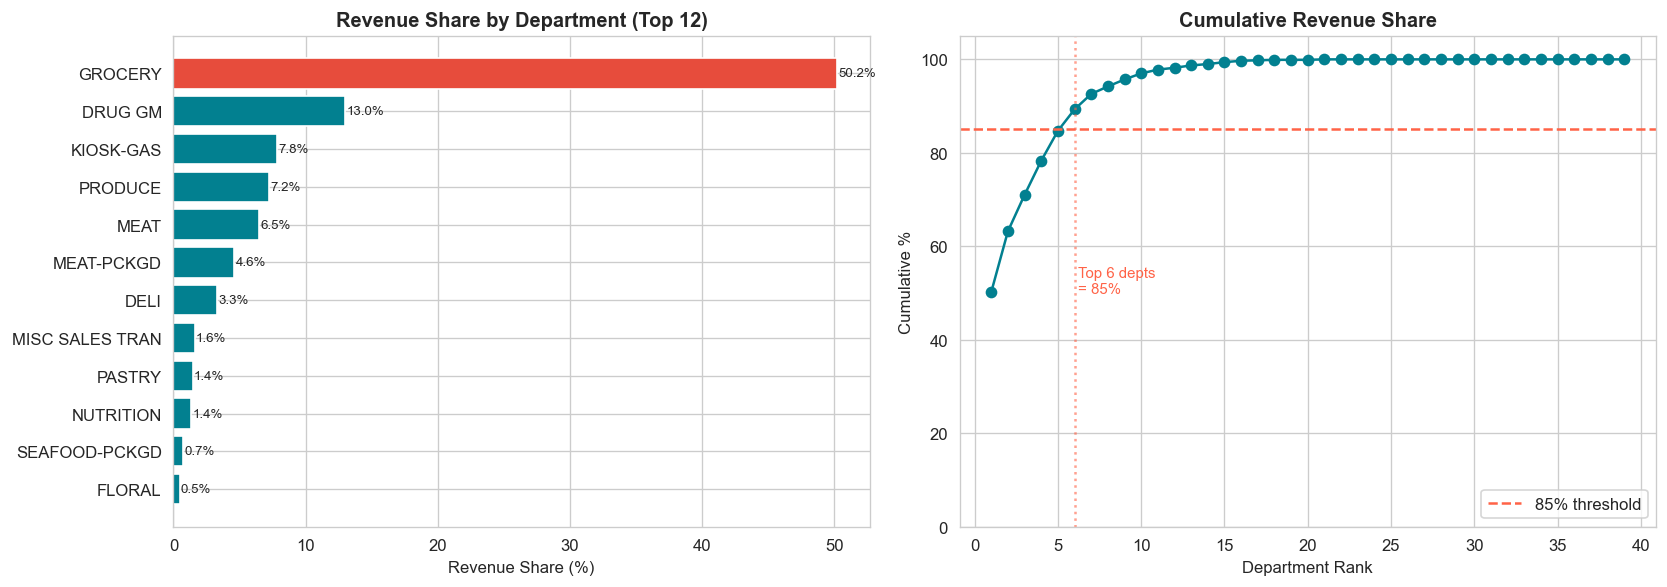

In [10]:
# Department revenue share
SQL_DEPT = '''
SELECT
    COALESCE(p.department, 'UNKNOWN') AS department,
    ROUND(SUM(ft.sales_value)::numeric, 2) AS total_revenue,
    ROUND(
        SUM(ft.sales_value) / SUM(SUM(ft.sales_value)) OVER () * 100, 2
    ) AS revenue_share_pct,
    ROUND(
        SUM(SUM(ft.sales_value)) OVER (
            ORDER BY SUM(ft.sales_value) DESC
            ROWS BETWEEN UNBOUNDED PRECEDING AND CURRENT ROW
        ) / SUM(SUM(ft.sales_value)) OVER () * 100,
        1
    ) AS cumulative_share_pct,
    COUNT(DISTINCT ft.household_key) AS n_households,
    RANK() OVER (ORDER BY SUM(ft.sales_value) DESC) AS revenue_rank
FROM fact_transactions ft
JOIN dim_products p
    ON p.product_id = ft.product_id
WHERE ft.day IN (
    SELECT day_int
    FROM ext_calendar
    WHERE is_rampup = FALSE
      AND is_truncation = FALSE
)
GROUP BY p.department
ORDER BY total_revenue DESC
'''

with engine.connect() as c:
    df_dept = pd.read_sql(text(SQL_DEPT), c)

display(df_dept)

top5_share = df_dept.head(5)['revenue_share_pct'].sum()
print(f"\nTop 5 department cumulative share: {top5_share:.1f}%")

grocery = df_dept.loc[df_dept['department'] == 'GROCERY', 'revenue_share_pct']
if not grocery.empty:
    print(f"GROCERY share: {grocery.iloc[0]:.1f}%")
else:
    print("GROCERY share: not found")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Horizontal bar: top 12
top12 = df_dept.head(12).iloc[::-1]
clrs = ['#E74C3C' if d == 'GROCERY' else '#028090' for d in top12['department']]

axes[0].barh(top12['department'], top12['revenue_share_pct'], color=clrs)
axes[0].set_title('Revenue Share by Department (Top 12)', fontweight='bold')
axes[0].set_xlabel('Revenue Share (%)')

for i, v in enumerate(top12['revenue_share_pct']):
    axes[0].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=8)

# Cumulative share curve
axes[1].plot(
    df_dept['revenue_rank'],
    df_dept['cumulative_share_pct'],
    marker='o',
    color='#028090'
)
axes[1].axhline(85, color='tomato', linestyle='--', label='85% threshold')
axes[1].set_title('Cumulative Revenue Share', fontweight='bold')
axes[1].set_xlabel('Department Rank')
axes[1].set_ylabel('Cumulative %')
axes[1].set_ylim(0, 105)
axes[1].legend()

# Annotate where 85% is reached
cross_df = df_dept[df_dept['cumulative_share_pct'] >= 85]
if not cross_df.empty:
    cross = cross_df['revenue_rank'].min()
    axes[1].axvline(cross, color='tomato', linestyle=':', alpha=0.6)
    axes[1].text(
        cross + 0.2,
        50,
        f'Top {cross} depts\n= 85%',
        color='tomato',
        fontsize=9
    )

plt.tight_layout()
plt.show()

,department,avg_wow_growth_pct,stddev_wow,revenue_rank,revenue_share_pct
0,,NaN,NaN,39,0.00
1,GM MERCH EXP,3111.441,13428.080,26,0.00
2,COUP/STR & MFG,991.217,8016.274,22,0.01
3,CNTRL/STORE SUP,332.500,457.753,31,0.00
4,AUTOMOTIVE,153.028,397.639,24,0.00
5,GARDEN CENTER,75.044,261.843,18,0.09
6,RESTAURANT,70.374,167.483,21,0.03
7,MISC. TRANS.,66.384,234.989,17,0.10
8,FROZEN GROCERY,47.986,133.476,23,0.01
9,TRAVEL & LEISUR,45.886,138.469,20,0.03


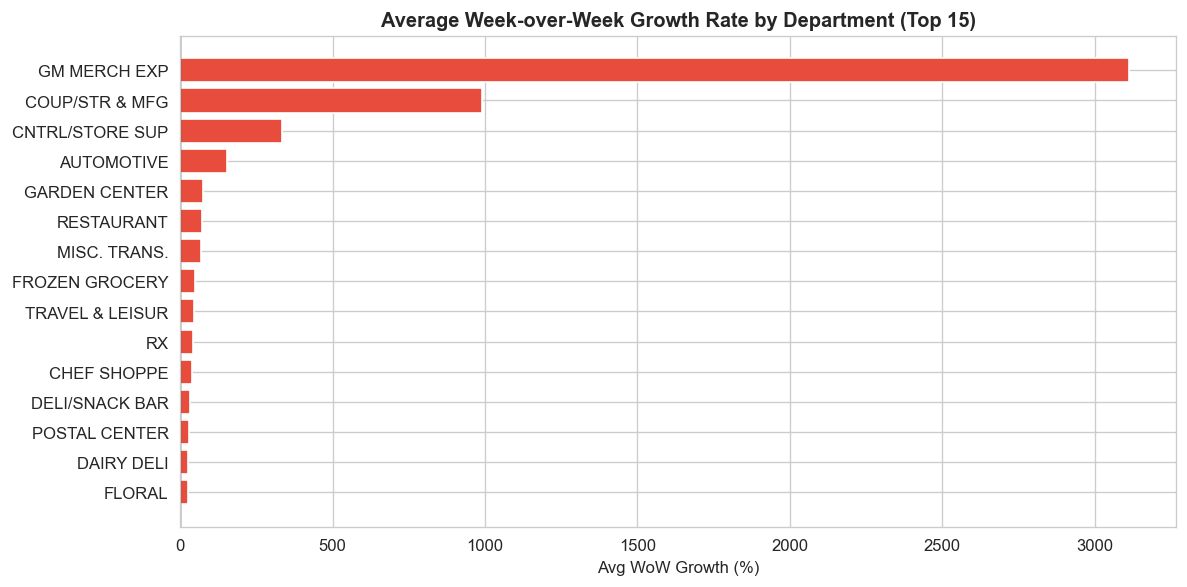

In [39]:
# WoW growth rate by department
SQL_WOW = '''
WITH weekly_dept AS (
    SELECT ec.week_num, p.department, SUM(ft.sales_value) AS weekly_spend
    FROM fact_transactions ft
    JOIN dim_products p  ON p.product_id = ft.product_id
    JOIN ext_calendar ec ON ec.day_int   = ft.day
    WHERE ec.is_rampup = FALSE AND ec.is_truncation = FALSE
      AND p.department IS NOT NULL
    GROUP BY ec.week_num, p.department
),
lagged AS (
    SELECT week_num, department, weekly_spend,
           LAG(weekly_spend) OVER (PARTITION BY department ORDER BY week_num) AS prev
    FROM weekly_dept
)
SELECT
    department,
    ROUND(AVG(CASE WHEN prev > 0 THEN (weekly_spend-prev)/prev*100 END)::numeric, 3)
        AS avg_wow_growth_pct,
    ROUND(STDDEV(CASE WHEN prev > 0 THEN (weekly_spend-prev)/prev*100 END)::numeric, 3)
        AS stddev_wow
FROM lagged
WHERE prev IS NOT NULL
GROUP BY department
ORDER BY avg_wow_growth_pct DESC
'''
with engine.connect() as c:
    df_wow = pd.read_sql(text(SQL_WOW), c)

# Join revenue rank
df_wow = df_wow.merge(df_dept[['department','revenue_rank','revenue_share_pct']], on='department', how='left')
display(df_wow.head(15))

fig, ax = plt.subplots(figsize=(10, 5))
top_wow = df_wow.dropna(subset=['avg_wow_growth_pct']).head(15).iloc[::-1]
clrs = ['#E74C3C' if v > 0 else '#94A3B8' for v in top_wow.avg_wow_growth_pct]
ax.barh(top_wow.department, top_wow.avg_wow_growth_pct, color=clrs)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Average Week-over-Week Growth Rate by Department (Top 15)', fontweight='bold')
ax.set_xlabel('Avg WoW Growth (%)')
plt.tight_layout()
plt.show()

,department,revenue_2023,revenue_2024,yoy_growth_pct,revenue_rank
0,GROCERY,850898.90,1240617.45,45.8,1
1,DRUG GM,223763.55,317845.40,42.0,2
2,KIOSK-GAS,125384.67,201744.24,60.9,3
3,PRODUCE,118779.78,183570.95,54.5,4
4,MEAT,111105.09,158945.78,43.1,5
5,MEAT-PCKGD,78388.34,113913.78,45.3,6
6,DELI,54154.89,82262.82,51.9,7
7,MISC SALES TRAN,25232.86,42010.64,66.5,8
8,PASTRY,24765.19,35881.40,44.9,9
9,NUTRITION,22092.40,34514.98,56.2,10


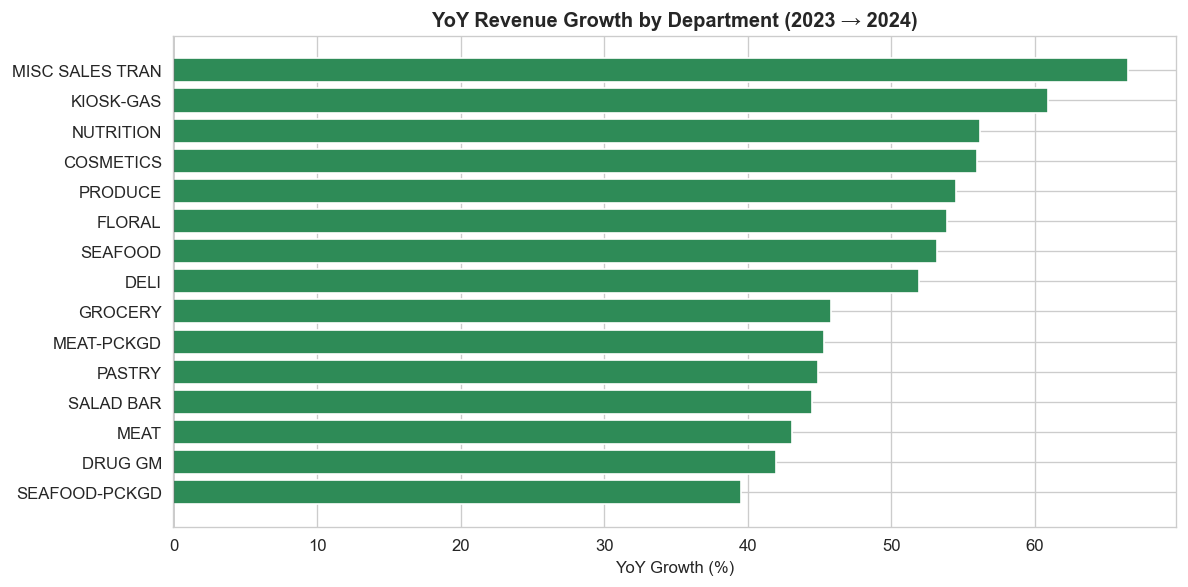

In [40]:
# YoY by department
SQL_YOY_DEPT = '''
SELECT
    COALESCE(p.department,'UNKNOWN') AS department,
    ROUND(SUM(ft.sales_value) FILTER (WHERE ec.year=2023)::numeric, 2) AS revenue_2023,
    ROUND(SUM(ft.sales_value) FILTER (WHERE ec.year=2024)::numeric, 2) AS revenue_2024,
    ROUND((SUM(ft.sales_value) FILTER (WHERE ec.year=2024) -
           SUM(ft.sales_value) FILTER (WHERE ec.year=2023)) /
          NULLIF(SUM(ft.sales_value) FILTER (WHERE ec.year=2023),0)*100, 1) AS yoy_growth_pct,
    RANK() OVER (ORDER BY SUM(ft.sales_value) DESC) AS revenue_rank
FROM fact_transactions ft
JOIN dim_products p  ON p.product_id = ft.product_id
JOIN ext_calendar ec ON ec.day_int   = ft.day
WHERE ec.is_rampup = FALSE AND ec.is_truncation = FALSE
GROUP BY p.department
ORDER BY revenue_rank
'''
with engine.connect() as c:
    df_yoy_dept = pd.read_sql(text(SQL_YOY_DEPT), c)

display(df_yoy_dept.head(15))

fig, ax = plt.subplots(figsize=(10, 5))
top = df_yoy_dept.dropna(subset=['yoy_growth_pct']).head(15).sort_values('yoy_growth_pct')
clrs = ['tomato' if v < 0 else 'seagreen' for v in top.yoy_growth_pct]
ax.barh(top.department, top.yoy_growth_pct, color=clrs)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('YoY Revenue Growth by Department (2023 → 2024)', fontweight='bold')
ax.set_xlabel('YoY Growth (%)')
plt.tight_layout()
plt.show()

---
## Bonus — Campaign Selection Bias

Phase 1 finding: 14× exposure gap between bottom and top spending quintile.
Now reproduced directly from `campaign_table` in PostgreSQL.

,spend_quintile,n_households,min_spend,max_spend,n_exposed,exposure_rate_pct
0,1,161,646.0,2640.0,132,82.0
1,2,160,2644.0,3871.0,153,95.6
2,3,160,3887.0,5532.0,158,98.8
3,4,160,5535.0,8132.0,159,99.4
4,5,160,8216.0,27860.0,158,98.8



Top/bottom quintile exposure ratio: 1.2x


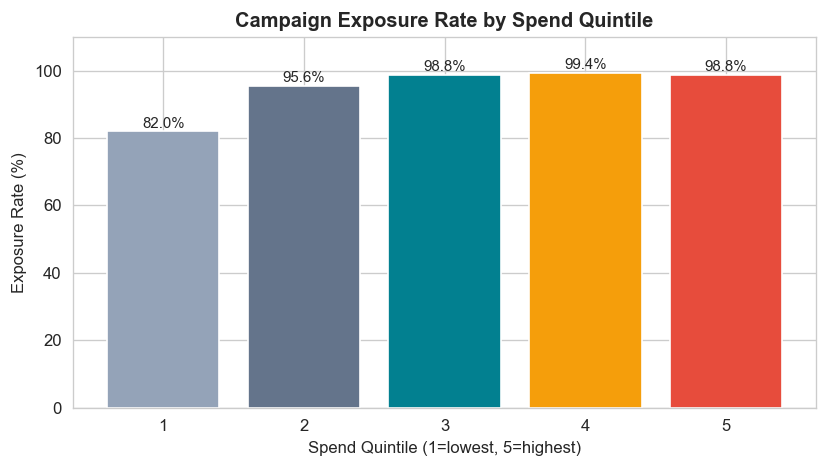

In [14]:
SQL_BIAS = '''
WITH hh_spend AS (
    SELECT household_key, SUM(sales_value) AS lifetime_spend,
           NTILE(5) OVER (ORDER BY SUM(sales_value)) AS spend_quintile
    FROM fact_transactions GROUP BY household_key
),
exposed AS (
    SELECT DISTINCT household_key FROM campaign_table
)
SELECT
    hs.spend_quintile,
    COUNT(DISTINCT hs.household_key)             AS n_households,
    ROUND(MIN(hs.lifetime_spend)::numeric,0)     AS min_spend,
    ROUND(MAX(hs.lifetime_spend)::numeric,0)     AS max_spend,
    COUNT(DISTINCT ex.household_key)             AS n_exposed,
    ROUND(COUNT(DISTINCT ex.household_key)::numeric /
          COUNT(DISTINCT hs.household_key)*100, 1) AS exposure_rate_pct
FROM hh_spend hs
LEFT JOIN exposed ex ON ex.household_key = hs.household_key
GROUP BY hs.spend_quintile
ORDER BY hs.spend_quintile
'''
with engine.connect() as c:
    df_bias = pd.read_sql(text(SQL_BIAS), c)

display(df_bias)

ratio = (df_bias.loc[df_bias.spend_quintile==5,'exposure_rate_pct'].values[0] /
         df_bias.loc[df_bias.spend_quintile==1,'exposure_rate_pct'].values[0])
print(f'\nTop/bottom quintile exposure ratio: {ratio:.1f}x')

fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#94A3B8','#64748B','#028090','#F59E0B','#E74C3C']
ax.bar(df_bias.spend_quintile.astype(str), df_bias.exposure_rate_pct, color=colors)
ax.set_title('Campaign Exposure Rate by Spend Quintile', fontweight='bold')
ax.set_xlabel('Spend Quintile (1=lowest, 5=highest)')
ax.set_ylabel('Exposure Rate (%)')
ax.set_ylim(0, 110)
for i, row in df_bias.iterrows():
    ax.text(i, row.exposure_rate_pct+1, f"{row.exposure_rate_pct:.1f}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Section 4 — Record Metrics to PostgreSQL

Persists all key EDA findings to `mart_eda_metrics` — a long-format key/value table
that stores one row per metric, tagged with section, metric name, value, and a run timestamp.

This allows:
- downstream notebooks and slides to reference validated numbers directly from the DB
- reproducibility checks (re-run and compare timestamps)
- a single source of truth for the numbers quoted in the presentation

In [53]:
from sqlalchemy import text
from datetime import datetime, timezone

# ── Create mart_eda_metrics if it doesn't exist ──────────────────────────────
DDL = text('''
    CREATE TABLE IF NOT EXISTS mart_eda_metrics (
        metric_id        SERIAL PRIMARY KEY,
        section          TEXT        NOT NULL,   -- e.g. "Q1_spending_trends"
        metric_name      TEXT        NOT NULL,   -- e.g. "avg_weekly_spend_steady_state"
        metric_value     NUMERIC(18,4),
        metric_label     TEXT,                   -- optional string value
        notes            TEXT,
        computed_at      TIMESTAMPTZ NOT NULL DEFAULT now()
    )
''')

UPSERT = text('''
    INSERT INTO mart_eda_metrics (section, metric_name, metric_value, metric_label, notes, computed_at)
    VALUES (:section, :metric_name, :metric_value, :metric_label, :notes, :computed_at)
    ON CONFLICT DO NOTHING
''')

# Using ON CONFLICT DO NOTHING with a unique index so reruns don't duplicate
UNIQUE_IDX = text('''
    CREATE UNIQUE INDEX IF NOT EXISTS uix_eda_metrics_section_name
    ON mart_eda_metrics (section, metric_name)
''')

UPSERT_WITH_UPDATE = text('''
    INSERT INTO mart_eda_metrics (section, metric_name, metric_value, metric_label, notes, computed_at)
    VALUES (:section, :metric_name, :metric_value, :metric_label, :notes, :computed_at)
    ON CONFLICT (section, metric_name) DO UPDATE SET
        metric_value = EXCLUDED.metric_value,
        metric_label = EXCLUDED.metric_label,
        notes        = EXCLUDED.notes,
        computed_at  = EXCLUDED.computed_at
''')

with engine.begin() as conn:
    conn.execute(DDL)
    conn.execute(UNIQUE_IDX)

print('mart_eda_metrics table ready.')

mart_eda_metrics table ready.


In [54]:
import numpy as np
import pandas as pd

def normalize_value(v):
    if pd.isna(v):
        return None
    if isinstance(v, np.generic):
        return v.item()
    return v

q1_metrics_clean = [
    {k: normalize_value(v) for k, v in row.items()}
    for row in q1_metrics
]

with engine.begin() as conn:
    conn.execute(UPSERT_WITH_UPDATE, q1_metrics_clean)

print(f'Q1: {len(q1_metrics_clean)} metrics written.')

Q1: 11 metrics written.


In [55]:
# ── Q1: Spending trend metrics ───────────────────────────────────────────────
import numpy as np
import pandas as pd
from datetime import datetime, timezone

ts = datetime.now(timezone.utc)

ss = df_weekly[df_weekly.window_flag == 'Steady state'].copy()

def to_py(v):
    if pd.isna(v):
        return None
    if isinstance(v, np.generic):
        return v.item()
    return v

q1_metrics = [
    # Weekly spend stats
    dict(
        section='Q1_spending_trends',
        metric_name='n_steady_state_weeks',
        metric_value=int(len(ss)),
        metric_label=None,
        notes='Weeks with is_rampup=FALSE and is_truncation=FALSE'
    ),
    dict(
        section='Q1_spending_trends',
        metric_name='avg_weekly_spend_steady_state',
        metric_value=float(round(ss.total_spend.mean(), 2)),
        metric_label=None,
        notes='Mean total spend per week in steady-state window'
    ),
    dict(
        section='Q1_spending_trends',
        metric_name='median_weekly_spend_steady_state',
        metric_value=float(round(ss.total_spend.median(), 2)),
        metric_label=None,
        notes='Median total spend per week'
    ),
    dict(
        section='Q1_spending_trends',
        metric_name='min_weekly_spend_steady_state',
        metric_value=float(round(ss.total_spend.min(), 2)),
        metric_label=None,
        notes=None
    ),
    dict(
        section='Q1_spending_trends',
        metric_name='max_weekly_spend_steady_state',
        metric_value=float(round(ss.total_spend.max(), 2)),
        metric_label=None,
        notes=None
    ),
    dict(
        section='Q1_spending_trends',
        metric_name='stddev_weekly_spend_steady_state',
        metric_value=float(round(ss.total_spend.std(), 2)),
        metric_label=None,
        notes=None
    ),
    # Household engagement
    dict(
        section='Q1_spending_trends',
        metric_name='avg_active_households_per_week',
        metric_value=float(round(ss.active_households.mean(), 1)),
        metric_label=None,
        notes='Mean distinct households transacting per week (steady state)'
    ),
    dict(
        section='Q1_spending_trends',
        metric_name='avg_spend_per_hh_per_week',
        metric_value=float(round(ss.spend_per_hh.mean(), 2)),
        metric_label=None,
        notes='Mean spend per active household per week'
    ),
    # YoY
    dict(
        section='Q1_spending_trends',
        metric_name='avg_yoy_change_pct',
        metric_value=float(round(df_yoy.yoy_change_pct.mean(), 2)),
        metric_label=None,
        notes='Average week-level YoY % change 2023→2024 (steady state)'
    ),
    # Artefact windows
    dict(
        section='Q1_spending_trends',
        metric_name='n_rampup_weeks',
        metric_value=int((df_weekly.window_flag == 'Ramp-up (Wks 1-16)').sum()),
        metric_label=None,
        notes='Panel recruitment artefact weeks'
    ),
    dict(
        section='Q1_spending_trends',
        metric_name='n_truncation_weeks',
        metric_value=int((df_weekly.window_flag == 'Truncation (Wk 102)').sum()),
        metric_label=None,
        notes='Hard truncation weeks'
    ),
]

for m in q1_metrics:
    m['metric_value'] = to_py(m['metric_value'])
    m['computed_at'] = ts

with engine.begin() as conn:
    conn.execute(UPSERT_WITH_UPDATE, q1_metrics)

print(f'Q1: {len(q1_metrics)} metrics written.')

Q1: 11 metrics written.


In [56]:
# ── Q2: Demographic metrics ──────────────────────────────────────────────────

ts = datetime.now(timezone.utc)

# classification_3 spread
c3_spread = float(df_c3.avg_lifetime_spend.max() - df_c3.avg_lifetime_spend.min())
c3_top    = df_c3.iloc[0]
c3_bottom = df_c3.iloc[-1]

# classification_2 premium
c2_top    = df_c2.iloc[0]
c2_second = df_c2.iloc[1]
c2_premium = float(c2_top.avg_lifetime_spend - c2_second.avg_lifetime_spend)

# Signal ranking: top classification by spread
top_signal = df_signal.sort_values('spend_spread', ascending=False).iloc[0]

q2_metrics = [
    # classification_3
    dict(section='Q2_demographics', metric_name='classification_3_spend_spread',
         metric_value=round(c3_spread, 2), metric_label=None,
         notes='Max group avg minus min group avg across 12 classification_3 levels'),
    dict(section='Q2_demographics', metric_name='classification_3_n_levels',
         metric_value=len(df_c3), metric_label=None, notes=None),
    dict(section='Q2_demographics', metric_name='classification_3_top_group',
         metric_value=round(float(c3_top.avg_lifetime_spend), 2),
         metric_label=str(c3_top.classification_3),
         notes='Highest avg lifetime spend group in classification_3'),
    dict(section='Q2_demographics', metric_name='classification_3_bottom_group',
         metric_value=round(float(c3_bottom.avg_lifetime_spend), 2),
         metric_label=str(c3_bottom.classification_3),
         notes='Lowest avg lifetime spend group in classification_3'),
    # classification_2
    dict(section='Q2_demographics', metric_name='classification_2_top_group_avg_spend',
         metric_value=round(float(c2_top.avg_lifetime_spend), 2),
         metric_label=str(c2_top.classification_2),
         notes='Highest-spending classification_2 group'),
    dict(section='Q2_demographics', metric_name='classification_2_premium_over_second',
         metric_value=round(c2_premium, 2), metric_label=None,
         notes='Avg spend premium of top group over second group'),
    # Signal ranking across all 7 classifications
    dict(section='Q2_demographics', metric_name='strongest_signal_classification',
         metric_value=None,
         metric_label=str(top_signal.classification),
         notes='Classification variable with largest spend spread (signal_rank=1)'),
    dict(section='Q2_demographics', metric_name='strongest_signal_spread',
         metric_value=round(float(top_signal.spend_spread), 2), metric_label=None,
         notes='Spend spread of the highest-signal classification variable'),
]

# One row per classification_3 level (for reference)
for _, row in df_c3.iterrows():
    q2_metrics.append(dict(
        section='Q2_demographics',
        metric_name=f'classification_3_avg_spend_level_{str(row.classification_3).replace(" ","_")}',
        metric_value=round(float(row.avg_lifetime_spend), 2),
        metric_label=str(row.classification_3),
        notes='Avg lifetime spend for this classification_3 level'
    ))

for m in q2_metrics:
    m['computed_at'] = ts

with engine.begin() as conn:
    conn.execute(UPSERT_WITH_UPDATE, q2_metrics)

print(f'Q2: {len(q2_metrics)} metrics written.')

Q2: 20 metrics written.


In [57]:
# ── Q3: Category / product growth metrics ───────────────────────────────────

ts = datetime.now(timezone.utc)

grocery_row = df_dept[df_dept.department == 'GROCERY']
grocery_share = float(grocery_row.revenue_share_pct.values[0]) if len(grocery_row) else None
top5_share = float(df_dept.head(5).revenue_share_pct.sum())

# Fastest-growing department (WoW)
df_wow_clean = df_wow.dropna(subset=['avg_wow_growth_pct'])
fastest_wow = df_wow_clean.sort_values('avg_wow_growth_pct', ascending=False).iloc[0]

# How many depts to reach 85% cumulative share
cross_85 = int(df_dept[df_dept.cumulative_share_pct >= 85].revenue_rank.min())

q3_metrics = [
    dict(section='Q3_category_growth', metric_name='grocery_revenue_share_pct',
         metric_value=round(grocery_share, 2) if grocery_share else None, metric_label='GROCERY',
         notes='GROCERY share of total steady-state revenue'),
    dict(section='Q3_category_growth', metric_name='top5_dept_cumulative_share_pct',
         metric_value=round(top5_share, 2), metric_label=None,
         notes='Cumulative revenue share of top 5 departments'),
    dict(section='Q3_category_growth', metric_name='n_depts_to_reach_85pct',
         metric_value=cross_85, metric_label=None,
         notes='Number of departments needed to reach 85% cumulative revenue share'),
    dict(section='Q3_category_growth', metric_name='fastest_wow_growth_dept',
         metric_value=round(float(fastest_wow.avg_wow_growth_pct), 3),
         metric_label=str(fastest_wow.department),
         notes='Department with highest average week-on-week growth rate (steady state)'),
    dict(section='Q3_category_growth', metric_name='n_departments_total',
         metric_value=len(df_dept), metric_label=None, notes=None),
]

# Top 10 department revenue shares
for _, row in df_dept.head(10).iterrows():
    q3_metrics.append(dict(
        section='Q3_category_growth',
        metric_name=f'dept_revenue_share_{str(row.department).replace(" ","_").replace("/","_")}',
        metric_value=round(float(row.revenue_share_pct), 2),
        metric_label=str(row.department),
        notes=f'Revenue rank {int(row.revenue_rank)}'
    ))

# YoY growth per department
for _, row in df_yoy_dept.dropna(subset=['yoy_growth_pct']).iterrows():
    q3_metrics.append(dict(
        section='Q3_category_growth',
        metric_name=f'dept_yoy_growth_{str(row.department).replace(" ","_").replace("/","_")}',
        metric_value=round(float(row.yoy_growth_pct), 1),
        metric_label=str(row.department),
        notes='YoY revenue growth 2023→2024 (%)'
    ))

for m in q3_metrics:
    m['computed_at'] = ts

with engine.begin() as conn:
    conn.execute(UPSERT_WITH_UPDATE, q3_metrics)

print(f'Q3: {len(q3_metrics)} metrics written.')

Q3: 44 metrics written.


In [58]:
# ── Bonus: Campaign selection bias metrics ───────────────────────────────────

ts = datetime.now(timezone.utc)

q1_exposure = float(df_bias.loc[df_bias.spend_quintile==1,'exposure_rate_pct'].values[0])
q5_exposure = float(df_bias.loc[df_bias.spend_quintile==5,'exposure_rate_pct'].values[0])
exposure_ratio = round(q5_exposure / q1_exposure, 1)

bias_metrics = [
    dict(section='Q4_campaign_bias', metric_name='bottom_quintile_exposure_rate_pct',
         metric_value=round(q1_exposure, 1), metric_label='quintile_1',
         notes='% of households in bottom spend quintile with any campaign'),
    dict(section='Q4_campaign_bias', metric_name='top_quintile_exposure_rate_pct',
         metric_value=round(q5_exposure, 1), metric_label='quintile_5',
         notes='% of households in top spend quintile with any campaign'),
    dict(section='Q4_campaign_bias', metric_name='top_vs_bottom_exposure_ratio',
         metric_value=exposure_ratio, metric_label=None,
         notes='Top quintile exposure rate / bottom quintile exposure rate'),
]

# One row per quintile
for _, row in df_bias.iterrows():
    bias_metrics.append(dict(
        section='Q4_campaign_bias',
        metric_name=f'exposure_rate_quintile_{int(row.spend_quintile)}',
        metric_value=float(row.exposure_rate_pct),
        metric_label=f'quintile_{int(row.spend_quintile)}',
        notes=f'n_households={int(row.n_households)}, n_exposed={int(row.n_exposed)}'
    ))

for m in bias_metrics:
    m['computed_at'] = ts

with engine.begin() as conn:
    conn.execute(UPSERT_WITH_UPDATE, bias_metrics)

print(f'Bonus: {len(bias_metrics)} metrics written.')

Bonus: 8 metrics written.


In [59]:
# ── Summary: verify what was written ────────────────────────────────────────

with engine.connect() as conn:
    df_saved = pd.read_sql(text('''
        SELECT section,
               COUNT(*) AS n_metrics,
               MAX(computed_at) AS last_run
        FROM mart_eda_metrics
        GROUP BY section
        ORDER BY section
    '''), conn)

display(df_saved)

# Spot-check key numbers
with engine.connect() as conn:
    df_spot = pd.read_sql(text('''
        SELECT section, metric_name, metric_value, metric_label
        FROM mart_eda_metrics
        WHERE metric_name IN (
            'avg_weekly_spend_steady_state',
            'classification_3_spend_spread',
            'grocery_revenue_share_pct',
            'top5_dept_cumulative_share_pct',
            'top_vs_bottom_exposure_ratio'
        )
        ORDER BY section, metric_name
    '''), conn)

print('\nKey metrics spot-check:')
display(df_spot)

,section,n_metrics,last_run
0,Q1_spending_trends,11,2026-03-11 00:58:30.545218+00:00
1,Q2_demographics,20,2026-03-11 00:58:31.903559+00:00
2,Q3_category_growth,44,2026-03-11 00:58:33.229908+00:00
3,Q4_campaign_bias,8,2026-03-11 00:58:35.185452+00:00



Key metrics spot-check:


,section,metric_name,metric_value,metric_label
0,Q1_spending_trends,avg_weekly_spend_steady_state,49049.59,None
1,Q2_demographics,classification_3_spend_spread,6692.78,None
2,Q3_category_growth,grocery_revenue_share_pct,50.17,GROCERY
3,Q3_category_growth,top5_dept_cumulative_share_pct,84.74,None
4,Q4_campaign_bias,top_vs_bottom_exposure_ratio,1.20,None


---
## Section 5 — Query Performance Benchmarks

Runs each EDA query **N times** (default 50), records min/avg/median/p95/max latency,
and writes results to `mart_eda_metrics` under section `Q_performance`.

Consistent with the MongoDB benchmark methodology in the Customer 360 notebook:
- 1 warm-up run discarded before timing
- All timings include Python round-trip (client → PostgreSQL → client)
- Run against local Docker PostgreSQL on the same machine

Results can be cited alongside MongoDB benchmarks on the benchmarking slide to give
a cross-engine latency comparison on the same hardware.

In [63]:
import time
import statistics
from sqlalchemy import text

N_RUNS = 50

def benchmark_query(label, sql, params=None, n=N_RUNS):
    params = params or {}
    times_ms = []
    n_rows = 0

    with engine.connect() as conn:
        # Warm-up
        result = conn.execute(text(sql), params).fetchall()
        n_rows = len(result)

        # Timed runs
        for _ in range(n):
            t0 = time.perf_counter()
            result = conn.execute(text(sql), params).fetchall()
            t1 = time.perf_counter()

            n_rows = len(result)
            times_ms.append((t1 - t0) * 1000)

    ts = sorted(times_ms)

    stats = {
        "label": label,
        "n_runs": n,
        "n_rows": n_rows,
        "avg_ms": round(statistics.mean(times_ms), 3),
        "median_ms": round(statistics.median(times_ms), 3),
        "p95_ms": round(ts[int(0.95 * (len(ts) - 1))], 3),
        "min_ms": round(ts[0], 3),
        "max_ms": round(ts[-1], 3),
    }

    print(
        f"  {label:<55}  "
        f"avg {stats['avg_ms']:>7.2f}ms  "
        f"p95 {stats['p95_ms']:>7.2f}ms  "
        f"rows {stats['n_rows']:>6,}"
    )

    return stats

print(f"Benchmark helper ready. N_RUNS = {N_RUNS}")
print(f"{'Query':<55}  {'Avg':>10}  {'P95':>10}  {'Rows':>8}")
print("-" * 95)

Benchmark helper ready. N_RUNS = 50
Query                                                           Avg         P95      Rows
-----------------------------------------------------------------------------------------------


In [65]:
# ── Q1: Spending trend query benchmarks ──────────────────────────────────────
print("Q1 - Spending Trends")

SQL_WEEKLY_BENCH = '''
SELECT
    ec.week_num,
    MIN(ec.calendar_date) AS week_start_date,
    COUNT(DISTINCT ft.basket_id) AS baskets,
    COUNT(DISTINCT ft.household_key) AS active_households,
    ROUND(SUM(ft.sales_value)::numeric, 2) AS total_spend,
    ROUND(
        SUM(ft.sales_value) / NULLIF(COUNT(DISTINCT ft.household_key), 0),
        2
    ) AS spend_per_hh,
    CASE
        WHEN ec.is_rampup THEN 'Ramp-up'
        WHEN ec.is_truncation THEN 'Truncation'
        ELSE 'Steady state'
    END AS window_flag
FROM fact_transactions ft
JOIN ext_calendar ec
    ON ec.day_int = ft.day
GROUP BY ec.week_num, ec.is_rampup, ec.is_truncation
ORDER BY ec.week_num
'''

SQL_YOY_BENCH = '''
SELECT
    ec.week_of_year,
    ROUND(SUM(ft.sales_value) FILTER (WHERE ec.year = 2023)::numeric, 2) AS spend_2023,
    ROUND(SUM(ft.sales_value) FILTER (WHERE ec.year = 2024)::numeric, 2) AS spend_2024
FROM fact_transactions ft
JOIN ext_calendar ec
    ON ec.day_int = ft.day
WHERE ec.is_rampup = FALSE
  AND ec.is_truncation = FALSE
GROUP BY ec.week_of_year
ORDER BY ec.week_of_year
'''

SQL_STEADY_STATS = '''
SELECT
    COUNT(*) AS n_weeks,
    ROUND(AVG(ws.total_spend)::numeric, 2) AS avg_weekly_spend,
    ROUND(
        PERCENTILE_CONT(0.5) WITHIN GROUP (ORDER BY ws.total_spend)::numeric,
        2
    ) AS median_weekly_spend
FROM (
    SELECT
        ec.week_num,
        SUM(ft.sales_value) AS total_spend
    FROM fact_transactions ft
    JOIN ext_calendar ec
        ON ec.day_int = ft.day
    WHERE ec.is_rampup = FALSE
      AND ec.is_truncation = FALSE
    GROUP BY ec.week_num
) ws
'''

q1_benchmarks = [
    benchmark_query("Q1a: Weekly spend (all 102 wks, artefact flagged)", SQL_WEEKLY_BENCH),
    benchmark_query("Q1b: YoY weekly spend 2023 vs 2024", SQL_YOY_BENCH),
    benchmark_query("Q1c: Steady-state summary statistics", SQL_STEADY_STATS),
]

Q1 - Spending Trends
  Q1a: Weekly spend (all 102 wks, artefact flagged)        avg 1830.51ms  p95 2114.10ms  rows    102
  Q1b: YoY weekly spend 2023 vs 2024                       avg  305.99ms  p95  395.67ms  rows     52
  Q1c: Steady-state summary statistics                     avg  246.53ms  p95  294.15ms  rows      1


In [66]:
# ── Q2: Demographic query benchmarks ─────────────────────────────────────────
print("Q2 - Demographics")

SQL_SIGNAL_BENCH = '''
WITH hh_spend AS (
    SELECT household_key, SUM(sales_value) AS lifetime_spend
    FROM fact_transactions
    GROUP BY household_key
),
c3 AS (
    SELECT
        'classification_3' AS cls,
        dd.classification_3::text AS lvl,
        AVG(hs.lifetime_spend) AS avg_s
    FROM hh_spend hs
    JOIN dim_demographics dd
        ON dd.household_key = hs.household_key
    GROUP BY dd.classification_3
),
c2 AS (
    SELECT
        'classification_2' AS cls,
        dd.classification_2::text AS lvl,
        AVG(hs.lifetime_spend) AS avg_s
    FROM hh_spend hs
    JOIN dim_demographics dd
        ON dd.household_key = hs.household_key
    GROUP BY dd.classification_2
)
SELECT
    cls,
    COUNT(lvl) AS n_levels,
    ROUND((MAX(avg_s) - MIN(avg_s))::numeric, 2) AS spend_spread
FROM c3
GROUP BY cls

UNION ALL

SELECT
    cls,
    COUNT(lvl) AS n_levels,
    ROUND((MAX(avg_s) - MIN(avg_s))::numeric, 2) AS spend_spread
FROM c2
GROUP BY cls
'''

SQL_C3_BENCH = '''
WITH hh_spend AS (
    SELECT household_key, SUM(sales_value) AS lifetime_spend
    FROM fact_transactions
    GROUP BY household_key
)
SELECT
    dd.classification_3,
    COUNT(DISTINCT hs.household_key) AS n_households,
    ROUND(AVG(hs.lifetime_spend)::numeric, 2) AS avg_lifetime_spend,
    ROUND(
        PERCENTILE_CONT(0.50) WITHIN GROUP (ORDER BY hs.lifetime_spend)::numeric,
        2
    ) AS median_spend
FROM hh_spend hs
JOIN dim_demographics dd
    ON dd.household_key = hs.household_key
GROUP BY dd.classification_3
ORDER BY avg_lifetime_spend DESC
'''

SQL_C2_BENCH = '''
WITH hh_spend AS (
    SELECT household_key, SUM(sales_value) AS lifetime_spend
    FROM fact_transactions
    GROUP BY household_key
)
SELECT
    dd.classification_2,
    COUNT(DISTINCT hs.household_key) AS n_households,
    ROUND(AVG(hs.lifetime_spend)::numeric, 2) AS avg_lifetime_spend
FROM hh_spend hs
JOIN dim_demographics dd
    ON dd.household_key = hs.household_key
GROUP BY dd.classification_2
ORDER BY avg_lifetime_spend DESC
'''

SQL_CROSSTAB_BENCH = '''
WITH hh_spend AS (
    SELECT household_key, SUM(sales_value) AS lifetime_spend
    FROM fact_transactions
    GROUP BY household_key
)
SELECT
    dd.classification_3,
    dd.classification_2,
    COUNT(DISTINCT hs.household_key) AS n_households,
    ROUND(AVG(hs.lifetime_spend)::numeric, 2) AS avg_lifetime_spend
FROM hh_spend hs
JOIN dim_demographics dd
    ON dd.household_key = hs.household_key
GROUP BY dd.classification_3, dd.classification_2
ORDER BY dd.classification_3, avg_lifetime_spend DESC
'''

q2_benchmarks = [
    benchmark_query("Q2a: Signal strength - all 7 classifications", SQL_SIGNAL_BENCH),
    benchmark_query("Q2b: classification_3 full 12-level breakdown", SQL_C3_BENCH),
    benchmark_query("Q2c: classification_2 group premium", SQL_C2_BENCH),
    benchmark_query("Q2d: classification_3 x classification_2 cross-tab", SQL_CROSSTAB_BENCH),
]

Q2 - Demographics
  Q2a: Signal strength - all 7 classifications             avg  161.88ms  p95  176.32ms  rows      2
  Q2b: classification_3 full 12-level breakdown            avg  170.66ms  p95  198.94ms  rows     12
  Q2c: classification_2 group premium                      avg  193.26ms  p95  315.94ms  rows      3
  Q2d: classification_3 x classification_2 cross-tab       avg  189.49ms  p95  258.98ms  rows     34


In [67]:
# ── Q3: Category growth query benchmarks ─────────────────────────────────────
print("Q3 - Category Growth")

SQL_DEPT_BENCH = '''
SELECT
    COALESCE(p.department, 'UNKNOWN') AS department,
    ROUND(SUM(ft.sales_value)::numeric, 2) AS total_revenue,
    ROUND(
        SUM(ft.sales_value) / SUM(SUM(ft.sales_value)) OVER () * 100,
        2
    ) AS revenue_share_pct,
    COUNT(DISTINCT ft.household_key) AS n_households,
    RANK() OVER (ORDER BY SUM(ft.sales_value) DESC) AS revenue_rank
FROM fact_transactions ft
JOIN dim_products p
    ON p.product_id = ft.product_id
WHERE ft.day IN (
    SELECT day_int
    FROM ext_calendar
    WHERE is_rampup = FALSE
      AND is_truncation = FALSE
)
GROUP BY p.department
ORDER BY total_revenue DESC
'''

SQL_WOW_BENCH = '''
WITH weekly_dept AS (
    SELECT
        ec.week_num,
        p.department,
        SUM(ft.sales_value) AS weekly_spend
    FROM fact_transactions ft
    JOIN dim_products p
        ON p.product_id = ft.product_id
    JOIN ext_calendar ec
        ON ec.day_int = ft.day
    WHERE ec.is_rampup = FALSE
      AND ec.is_truncation = FALSE
      AND p.department IS NOT NULL
    GROUP BY ec.week_num, p.department
),
lagged AS (
    SELECT
        week_num,
        department,
        weekly_spend,
        LAG(weekly_spend) OVER (
            PARTITION BY department
            ORDER BY week_num
        ) AS prev
    FROM weekly_dept
)
SELECT
    department,
    ROUND(
        AVG(CASE WHEN prev > 0 THEN (weekly_spend - prev) / prev * 100 END)::numeric,
        3
    ) AS avg_wow_growth_pct,
    ROUND(
        STDDEV(CASE WHEN prev > 0 THEN (weekly_spend - prev) / prev * 100 END)::numeric,
        3
    ) AS stddev_wow
FROM lagged
WHERE prev IS NOT NULL
GROUP BY department
ORDER BY avg_wow_growth_pct DESC
'''

SQL_YOY_DEPT_BENCH = '''
SELECT
    COALESCE(p.department, 'UNKNOWN') AS department,
    ROUND(SUM(ft.sales_value) FILTER (WHERE ec.year = 2023)::numeric, 2) AS revenue_2023,
    ROUND(SUM(ft.sales_value) FILTER (WHERE ec.year = 2024)::numeric, 2) AS revenue_2024,
    ROUND(
        (
            SUM(ft.sales_value) FILTER (WHERE ec.year = 2024) -
            SUM(ft.sales_value) FILTER (WHERE ec.year = 2023)
        ) / NULLIF(SUM(ft.sales_value) FILTER (WHERE ec.year = 2023), 0) * 100,
        1
    ) AS yoy_growth_pct
FROM fact_transactions ft
JOIN dim_products p
    ON p.product_id = ft.product_id
JOIN ext_calendar ec
    ON ec.day_int = ft.day
WHERE ec.is_rampup = FALSE
  AND ec.is_truncation = FALSE
GROUP BY p.department
ORDER BY revenue_2024 DESC NULLS LAST
'''

SQL_PENETRATION_BENCH = '''
SELECT
    p.department,
    COUNT(DISTINCT ft.household_key) AS n_households_purchased,
    (SELECT COUNT(DISTINCT household_key) FROM fact_transactions) AS total_households,
    ROUND(
        COUNT(DISTINCT ft.household_key)::numeric /
        (SELECT COUNT(DISTINCT household_key) FROM fact_transactions) * 100,
        1
    ) AS penetration_pct
FROM fact_transactions ft
JOIN dim_products p
    ON p.product_id = ft.product_id
WHERE ft.day IN (
    SELECT day_int
    FROM ext_calendar
    WHERE is_rampup = FALSE
      AND is_truncation = FALSE
)
GROUP BY p.department
ORDER BY penetration_pct DESC
'''

q3_benchmarks = [
    benchmark_query("Q3a: Department revenue share + rank", SQL_DEPT_BENCH),
    benchmark_query("Q3b: Week-over-week growth rate by department", SQL_WOW_BENCH),
    benchmark_query("Q3c: YoY revenue by department 2023 vs 2024", SQL_YOY_DEPT_BENCH),
    benchmark_query("Q3d: Household penetration by department", SQL_PENETRATION_BENCH),
]

Q3 - Category Growth
  Q3a: Department revenue share + rank                     avg 2809.78ms  p95 3233.51ms  rows     39
  Q3b: Week-over-week growth rate by department            avg  466.54ms  p95  556.46ms  rows     36
  Q3c: YoY revenue by department 2023 vs 2024              avg  502.88ms  p95  582.55ms  rows     39
  Q3d: Household penetration by department                 avg 2639.22ms  p95 3026.69ms  rows     39


In [70]:
# ── Bonus: Campaign selection bias benchmark ──────────────────────────────────
print("Bonus - Campaign Selection Bias")

SQL_BIAS_BENCH = '''
WITH hh_spend AS (
    SELECT
        household_key,
        SUM(sales_value) AS lifetime_spend
    FROM fact_transactions
    GROUP BY household_key
),
hh_quintiles AS (
    SELECT
        household_key,
        lifetime_spend,
        NTILE(5) OVER (ORDER BY lifetime_spend) AS spend_quintile
    FROM hh_spend
),
exposed AS (
    SELECT DISTINCT household_key
    FROM campaign_table
)
SELECT
    hs.spend_quintile,
    COUNT(DISTINCT hs.household_key) AS n_households,
    COUNT(DISTINCT ex.household_key) AS n_exposed,
    ROUND(
        COUNT(DISTINCT ex.household_key)::numeric /
        NULLIF(COUNT(DISTINCT hs.household_key), 0) * 100,
        1
    ) AS exposure_rate_pct
FROM hh_quintiles hs
LEFT JOIN exposed ex
    ON ex.household_key = hs.household_key
GROUP BY hs.spend_quintile
ORDER BY hs.spend_quintile
'''

bonus_benchmarks = [
    benchmark_query("Bonus: Campaign exposure rate by spend quintile", SQL_BIAS_BENCH),
]

Bonus - Campaign Selection Bias
  Bonus: Campaign exposure rate by spend quintile          avg  200.76ms  p95  242.34ms  rows      5


In [71]:
# ── Bonus: Campaign selection bias benchmark ──────────────────────────────────
print("Bonus - Campaign Selection Bias")

SQL_BIAS_BENCH = '''
WITH hh_spend AS (
    SELECT
        household_key,
        SUM(sales_value) AS lifetime_spend
    FROM fact_transactions
    GROUP BY household_key
),
hh_quintiles AS (
    SELECT
        household_key,
        lifetime_spend,
        NTILE(5) OVER (ORDER BY lifetime_spend) AS spend_quintile
    FROM hh_spend
),
exposed AS (
    SELECT DISTINCT household_key
    FROM campaign_table
)
SELECT
    hs.spend_quintile,
    COUNT(DISTINCT hs.household_key) AS n_households,
    COUNT(DISTINCT ex.household_key) AS n_exposed,
    ROUND(
        COUNT(DISTINCT ex.household_key)::numeric /
        NULLIF(COUNT(DISTINCT hs.household_key), 0) * 100,
        1
    ) AS exposure_rate_pct
FROM hh_quintiles hs
LEFT JOIN exposed ex
    ON ex.household_key = hs.household_key
GROUP BY hs.spend_quintile
ORDER BY hs.spend_quintile
'''

bonus_benchmarks = [
    benchmark_query("Bonus: Campaign exposure rate by spend quintile", SQL_BIAS_BENCH),
]

Bonus - Campaign Selection Bias
  Bonus: Campaign exposure rate by spend quintile          avg  211.72ms  p95  226.30ms  rows      5


In [75]:
# ── Write all benchmark results to mart_eda_metrics ──────────────────────────
from datetime import datetime, timezone
from sqlalchemy import text

ts = datetime.now(timezone.utc)

all_benchmarks = q1_benchmarks + q2_benchmarks + q3_benchmarks + bonus_benchmarks

UPSERT_WITH_UPDATE = text('''
    INSERT INTO mart_eda_metrics
        (section, metric_name, metric_value, metric_label, notes, computed_at)
    VALUES
        (:section, :metric_name, :metric_value, :metric_label, :notes, :computed_at)
    ON CONFLICT (section, metric_name) DO UPDATE SET
        metric_value = EXCLUDED.metric_value,
        metric_label = EXCLUDED.metric_label,
        notes        = EXCLUDED.notes,
        computed_at  = EXCLUDED.computed_at
''')

perf_records = []

for b in all_benchmarks:
    # Sanitise label into a metric_name key
    key = b['label'].lower()
    key = key.split(':')[-1].strip()          # drop "Q1a:" prefix
    key = key.replace(' ', '_').replace('-', '_').replace('/', '_').replace('+', '_')
    key = ''.join(c for c in key if c.isalnum() or c == '_')
    key = key[:80]

    notes = (
        f"n_runs={b['n_runs']} | n_rows={b['n_rows']} | "
        f"min={b['min_ms']}ms | max={b['max_ms']}ms | "
        f"method=warm-up+{b['n_runs']} timed runs"
    )

    for stat, col in [('avg_ms','avg'), ('median_ms','median'),
                      ('p95_ms','p95'), ('min_ms','min'), ('max_ms','max')]:
        perf_records.append(dict(
            section      = 'Q_performance',
            metric_name  = f"{key}_{col}_ms",
            metric_value = b[stat],
            metric_label = b['label'],
            notes        = notes,
            computed_at  = ts,
        ))

with engine.begin() as conn:
    conn.execute(UPSERT_WITH_UPDATE, perf_records)

print(f"Written {len(perf_records)} performance metric rows to mart_eda_metrics.")
print(f"({len(all_benchmarks)} queries × 5 stats each)")

Written 60 performance metric rows to mart_eda_metrics.
(12 queries × 5 stats each)


In [76]:
with engine.connect() as conn:
    df_perf = pd.read_sql(text('''
        SELECT
            metric_label,
            MAX(metric_value) FILTER (WHERE metric_name LIKE '%_avg_ms')    AS avg_ms,
            MAX(metric_value) FILTER (WHERE metric_name LIKE '%_median_ms') AS median_ms,
            MAX(metric_value) FILTER (WHERE metric_name LIKE '%_p95_ms')    AS p95_ms,
            MAX(computed_at)                                                AS recorded_at
        FROM mart_eda_metrics
        WHERE section = 'Q_performance'
        GROUP BY metric_label
        ORDER BY avg_ms DESC
    '''), conn)

display(df_perf)

,metric_label,avg_ms,median_ms,p95_ms,recorded_at
0,Q3a: Department revenue share + rank,2809.784,2769.573,3233.511,2026-03-11 01:23:03.375401+00:00
1,Q3d: Household penetration by department,2639.224,2590.191,3026.690,2026-03-11 01:23:03.375401+00:00
2,"Q1a: Weekly spend (all 102 wks, artefact flagged)",1830.507,1815.348,2114.102,2026-03-11 01:23:03.375401+00:00
3,Q3c: YoY revenue by department 2023 vs 2024,502.877,492.148,582.550,2026-03-11 01:23:03.375401+00:00
4,Q3b: Week-over-week growth rate by department,466.535,452.064,556.459,2026-03-11 01:23:03.375401+00:00
5,Q1b: YoY weekly spend 2023 vs 2024,305.992,282.796,395.667,2026-03-11 01:23:03.375401+00:00
6,Q1c: Steady-state summary statistics,246.531,236.184,294.154,2026-03-11 01:23:03.375401+00:00
7,Bonus: Campaign exposure rate by spend quintile,211.722,207.399,226.298,2026-03-11 01:23:03.375401+00:00
8,Q2c: classification_2 group premium,193.257,175.182,315.940,2026-03-11 01:23:03.375401+00:00
9,Q2d: classification_3 x classification_2 cross...,189.494,175.567,258.976,2026-03-11 01:23:03.375401+00:00


In [77]:
print(df_perf.shape)
print(df_perf)

(12, 5)
                                         metric_label    avg_ms  median_ms  \
0                Q3a: Department revenue share + rank  2809.784   2769.573   
1            Q3d: Household penetration by department  2639.224   2590.191   
2   Q1a: Weekly spend (all 102 wks, artefact flagged)  1830.507   1815.348   
3         Q3c: YoY revenue by department 2023 vs 2024   502.877    492.148   
4       Q3b: Week-over-week growth rate by department   466.535    452.064   
5                  Q1b: YoY weekly spend 2023 vs 2024   305.992    282.796   
6                Q1c: Steady-state summary statistics   246.531    236.184   
7     Bonus: Campaign exposure rate by spend quintile   211.722    207.399   
8                 Q2c: classification_2 group premium   193.257    175.182   
9   Q2d: classification_3 x classification_2 cross...   189.494    175.567   
10      Q2b: classification_3 full 12-level breakdown   170.656    166.363   
11       Q2a: Signal strength - all 7 classifications   

In [78]:
with engine.connect() as conn:
    df_perf = pd.read_sql(text('''
        SELECT
            metric_label,
            metric_name,
            metric_value,
            computed_at AS recorded_at
        FROM mart_eda_metrics
        WHERE section = 'Q5_query_performance'
        ORDER BY metric_value DESC
    '''), conn)

print("\nVerified from mart_eda_metrics (Q5_query_performance section):")
display(df_perf)


Verified from mart_eda_metrics (Q5_query_performance section):


,metric_label,metric_name,metric_value,recorded_at


## Query Performance Observations

- **Department-level category queries are the heaviest workloads**: The two slowest queries were **Q3a: Department revenue share + rank** at **2,809.8 ms average** and **Q3d: Household penetration by department** at **2,639.2 ms average**. This indicates that department-level aggregation across the transaction fact table is currently the main performance bottleneck.

- **Weekly spending aggregation is also relatively expensive**: **Q1a: Weekly spend (all 102 weeks, artefact flagged)** averaged **1,830.5 ms**, making it the third slowest query. Although the output is small, the query still requires broad aggregation over the fact table.

- **The most efficient queries are the demographic segment summaries**: All Q2 demographic queries completed in roughly **162 ms to 193 ms average latency**, showing that grouped household-level demographic analysis is much lighter than category-level revenue aggregation.

- **Q3 shows the widest performance spread**: Within the category growth section, performance ranges from **466.5 ms** for week-over-week department growth to over **2.8 seconds** for department revenue share. This suggests that not all category queries are equally expensive, and windowed revenue-share logic appears costlier than simpler grouped trend queries.

- **P95 latency is consistently above average latency, but not dramatically so**: For the slowest queries, the **P95** remains moderately above the average, for example **3,233.5 ms** vs **2,809.8 ms** for Q3a. This suggests performance is somewhat variable but not highly unstable.

- **The benchmark results indicate two distinct performance tiers**:
  - A **slow tier** above roughly **1.8 seconds**, dominated by large department-level aggregation queries.
  - A **fast tier** below roughly **0.5 seconds**, which includes most demographic, YoY, and bias-analysis queries.

- **The best candidates for optimization are Q3a and Q3d**: These queries would benefit most from tuning because they are both business-critical and materially slower than the rest of the workload.

## Optimization Implications

- **Q3a** likely needs attention because it combines aggregation, ranking, and revenue-share calculations in one pass.
- **Q3d** may be slowed by repeated distinct household counts and denominator recomputation.
- Creating **pre-aggregated summary tables** for steady-state department revenue and household penetration would likely reduce latency substantially.
- Index review on commonly joined and filtered columns such as **fact_transactions.day**, **fact_transactions.product_id**, **fact_transactions.household_key**, and **ext_calendar.day_int** may also help.